## CartPole RL with MultiBanditNet (GRPO)

### 1. Introduction

This notebook demonstrates RL on CartPole-v1 using
**Group Relative Policy Optimization (GRPO)**.

GRPO replaces PPO's value-function advantages with
**group-relative advantages** normalized within a group
of trajectories, plus a KL-divergence penalty.
It is **critic-free** (no value network needed).

### 2. Methodology

1. CartPole-v1 via Gymnasium.
2. MultiBanditNet (option + action + termination heads).
3. GRPO training: group_size trajectories per epoch,
   per-timestep return normalization,
   clipped objective + KL penalty.
4. Pygame visualization.

### GRPO vs PPO

| Aspect | PPO | GRPO |
|---|---|---|
| Advantage | GAE + value fn | Group-relative norm |
| Value net | Required | Not needed |
| KL penalty | No | Yes (beta_kl) |
| Trajs/epoch | 1 | group_size |

### GRPO Equations

**Advantage normalization:**

$$
A_i =
\frac{R_i - \operatorname{mean}(R)}
{\operatorname{std}(R) + \epsilon}
$$

**Clipped objective:** same as PPO

$$
L_{\mathrm{clip}}
=
\mathbb{E}_i
\left[
\min\left(
r_i(\theta) A_i,\,
\operatorname{clip}\left(r_i(\theta), 1-\epsilon, 1+\epsilon\right) A_i
\right)
\right]
$$

where

$$
r_i(\theta)
=
\frac{\pi_\theta(a_i \mid x_i)}
{\pi_{\theta_{\mathrm{old}}}(a_i \mid x_i)}
$$

**KL penalty:**

$$
L_{\mathrm{KL}}
=
\beta_{\mathrm{KL}}
\mathbb{E}_i
\left[
\left(\log r_i(\theta)\right)^2
\right]
$$

**Loss:**

$$
L
=
L_{\mathrm{clip}}
+
L_{\mathrm{KL}}
-
\beta \mathcal{H}
$$


In [1]:
%%capture
import sys

# Añade el directorio principal al path de búsqueda para importar módulos desde esa ubicación
sys.path.insert(0, "..")

import numpy as np
import pygame
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import clear_output
from PIL import Image
from pygame.locals import *

from likelihood.models.deep import MultiBanditNet
from likelihood.tools import train_model_with_episodes, display_network_analysis

In [2]:
def render_with_pygame(env):
    # Inicializar Pygame
    pygame.init()

    DISPLAYSURF = pygame.display.set_mode((625, 400), 0, 32)
    clock = pygame.time.Clock()
    pygame.display.flip()

    def print_summary(text, cood, size):
        font = pygame.font.Font(pygame.font.get_default_font(), size)
        text_surface = font.render(text, True, (125, 125, 125))
        DISPLAYSURF.blit(text_surface, cood)

    done = False
    count = 0
    steps = 0
    done = False
    state, _ = env.reset()
    steps += 1
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    sample_state_tensor = []
    while count < 10_000:
        pygame.event.get()
        steps += 1

        for event in pygame.event.get():
            if event.type == QUIT:
                pygame.quit()
                raise Exception("training ended")
        state_tensor = (
            torch.tensor(state[0] if type(state) == tuple else state, dtype=torch.float32)
            .unsqueeze(0)
            .to(device)
        )
        sample_state_tensor.append(state_tensor.to("cpu"))
        option_probs, action_probs, termination_probs, selected_option, action = model(state_tensor)
        next_state, reward, done, truncated, info = env.step(action.item())
        print("state:", state)
        print("action taked:", action.item())
        clear_output(wait=True)

        image = env.render()

        image = Image.fromarray(image, "RGB")
        mode, size, data = image.mode, image.size, image.tobytes()
        image = pygame.image.fromstring(data, size, mode)

        DISPLAYSURF.blit(image, (0, 0))
        print_summary("Step {}".format(steps), (10, 10), 15)
        pygame.display.update()
        clock.tick(10)
        count += 1
        if done:
            print_summary("Episode ended !".format(steps), (100, 100), 30)
            pygame.quit()
            return torch.stack(sample_state_tensor).numpy()

            done = False
        state = next_state

    pygame.quit()
    return torch.stack(sample_state_tensor).numpy()

Episode      Loss     Best Loss         Status               Avg Loss   ε
1        -0.0513      inf             Updated               -0.0513    1.000
2        -0.0621      inf             Updated               -0.0567    0.991
3        -0.1333      inf             Updated               -0.0822    0.981
4        -0.0391      inf             No Improvement        -0.0714    0.972
5        0.1125       inf             Updated               -0.0346    0.963
6        -0.1206      inf             Updated               -0.0490    0.953
7        0.1671       inf             No Improvement        -0.0181    0.944
8        0.0291       inf             Updated               -0.0122    0.935
9        0.1482       inf             Updated               0.0056     0.927
10       -0.0938      inf             Updated               -0.0043    0.918
11       -0.0115      inf             No Improvement        -0.0050    0.909
12       0.1030       inf             Updated               0.0040     0.901
13

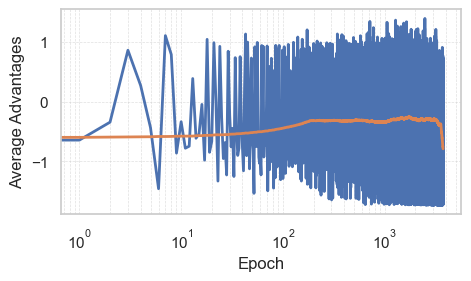

In [3]:
# Initialize environment, model, and optimizer
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode="rgb_array")
state_dim = env.observation_space.shape[0]
num_options = 2
num_actions = env.action_space.n

num_episodes = 100
num_layers = 1

model = MultiBanditNet(
    state_dim,
    num_options=num_options,
    num_actions_per_option=num_actions,
    num_layers=num_layers,
    activation=nn.ReLU(),
)
state = torch.tensor(np.random.randn(state_dim), dtype=torch.float32)
option_probs, action_probs, termination_prob, selected_option, action = model(state)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train with GRPO mode
# - group_size: trajectories per group for advantage normalization
# - beta_kl:    KL-divergence penalty coefficient
model, final_loss = train_model_with_episodes(
    model,
    optimizer,
    env,
    num_episodes,
    mode="grpo_mode",
    group_size=4,
    beta_kl=0.04,
)

In [4]:
%%capture
sample_state_tensor = render_with_pygame(env)

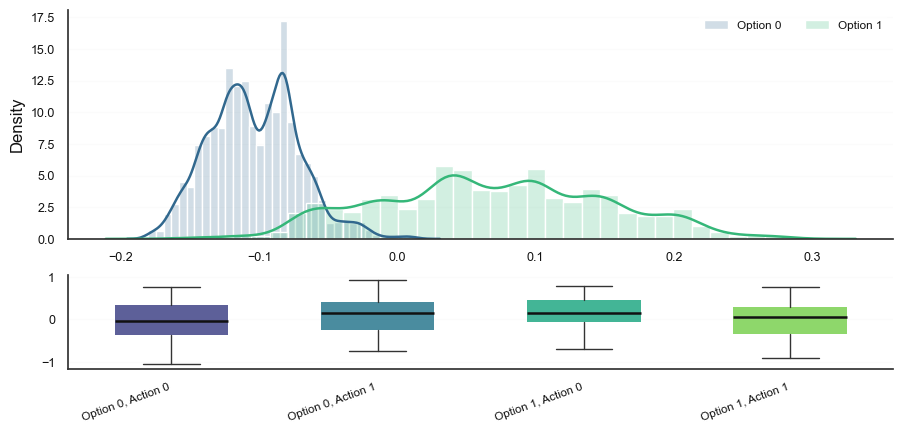

,Mean,Std,Min,Max,Range,Variance,Prob Mean,Prob Std
Option 0,-0.10358,0.03191,-0.18036,0.01554,0.19589,0.00102,0.45732,0.02120
Option 1,0.06788,0.08194,-0.17203,0.29260,0.46463,0.00671,0.54268,0.02120


,Mean,Std,Min,Max,Range,Variance,Prob Mean,Prob Std
"Option 0, Action 0",-0.04053,0.43840,-1.06170,0.75656,1.81825,0.19219,0.46533,0.18924
"Option 0, Action 1",0.12211,0.41254,-0.74179,0.93554,1.67733,0.17019,0.53467,0.18924
"Option 1, Action 0",0.17129,0.31586,-0.70080,0.79254,1.49335,0.09977,0.53304,0.16443
"Option 1, Action 1",0.02131,0.40445,-0.92239,0.76441,1.68680,0.16358,0.46696,0.16443


In [5]:
display_network_analysis(model, sample_state_tensor)

In [6]:
model_path = "./rf_model_grpo.pth"
torch.save(model.state_dict(), model_path)

In [7]:
model = MultiBanditNet(
    state_dim,
    num_options=num_options,
    num_actions_per_option=num_actions,
    num_layers=num_layers,
    activation=nn.ReLU(),
)

model.load_state_dict(
    torch.load(
        model_path,
        weights_only=True,
    ),
)

model.eval()

MultiBanditNet(
  (activation): ReLU()
  (action_networks): ModuleList(
    (0-1): 2 x Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=2, bias=True)
    )
  )
  (option_network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
  (termination_network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
    (4): Sigmoid()
  )
  (value_network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

### 3. Analysis and Results

MultiBanditNet learned CartPole via GRPO over 100 episodes.

Key observations:
- No value network needed (critic-free).
- Group normalization with group_size=4.
- KL penalty (beta_kl=0.04) stabilizes updates.

### 4. Conclusions

GRPO works well with MultiBanditNet. Advantages over PPO:
1. Simpler architecture (no critic).
2. Built-in KL regularization.
3. Tunable group_size.

Try: compare GRPO vs PPO, tune group_size / beta_kl.
